# 5. Modelagem — Regressão linear simples

Quinta fase do CRISP-DM. Aqui o objetivo é construir um modelo preditivo enxuto e ver até onde ele chega. Em vez de jogar todas as variáveis dentro de uma regressão múltipla, escolhi um caminho diferente: usar apenas o `delivery_delay_days` como preditor e medir o quanto essa variável sozinha consegue explicar do NPS.

A justificativa vem da EDA. No notebook 04, o modelo agregado com mais de 10 variáveis chegou a R² de 0,56, mas o `delivery_delay_days` sozinho já explicava 0,36 e dominava o ranking de importância. A pergunta natural é: vale a complexidade adicional? Um modelo de uma variável só é mais simples de explicar para gestores, mais fácil de manter, e responde direto à pergunta de negócio que vinha sendo construída desde o notebook 01: "atraso na entrega é a alavanca certa para mexer no NPS?".

A regressão linear simples também tem a vantagem didática de ser exatamente a técnica vista na fase de Estatística (Aula 5), o que mantém o trabalho dentro do escopo do que aprendemos no curso.

## 5.1 Carregamento e setup

Mesmo padrão dos notebooks anteriores. Carrego o dataset processado pela função do módulo `src/nps/data.py`, configuro o tema visual e defino os caminhos de saída para figuras desta fase.

In [1]:
# Bibliotecas principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Para o modelo, vou usar duas bibliotecas com proposito diferente:
# - statsmodels: melhor para interpretacao (coeficientes, p-valores, intervalos)
# - sklearn: melhor para o split treino/teste e calculo direto de metricas
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Funcoes do nosso modulo
from nps.data import carregar_dataset_processado

# Reprodutibilidade
SEMENTE_ALEATORIA = 42
np.random.seed(SEMENTE_ALEATORIA)

# Configuracao visual
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Caminhos para esse notebook
RAIZ_PROJETO = Path.cwd().parent
PASTA_FIGURAS = RAIZ_PROJETO / "reports" / "figures" / "05_modelagem_regressao"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Carrega o dataset processado
dados = carregar_dataset_processado()

print(f"Dataset carregado: {dados.shape[0]:,} linhas x {dados.shape[1]} colunas")
print(f"Target: nps_score (range {dados['nps_score'].min():.1f} a {dados['nps_score'].max():.1f})")
print(f"Preditor escolhido: delivery_delay_days (range {dados['delivery_delay_days'].min()} a {dados['delivery_delay_days'].max()})")

Dataset carregado: 2,500 linhas x 23 colunas
Target: nps_score (range 0.0 a 10.0)
Preditor escolhido: delivery_delay_days (range 0 a 8)


Tudo carregado. A próxima seção define formalmente o modelo e separa o dataset em treino e teste antes de ajustar a regressão.

## 5.2 Definição do modelo e separação treino/teste

O modelo é direto: ajustar uma reta que descreve como o `nps_score` varia conforme o `delivery_delay_days`. Em formato matemático, é uma equação do tipo `nps = a + b * delivery_delay_days`, onde `a` é o ponto onde a reta cruza o eixo y (intercepto) e `b` é a inclinação (quanto o NPS varia para cada dia adicional de atraso). Esses dois números é o que o algoritmo vai estimar a partir dos dados.

### Por que separar treino e teste

Antes de ajustar o modelo, vou separar os 2.500 registros em duas partes. Uma parte (80% das linhas, escolhidas aleatoriamente) vai ser usada para o algoritmo aprender os coeficientes — o conjunto de **treino**. A outra parte (20%) fica de fora desse processo e só vai ser usada depois para medir como o modelo se sai em dados que ele nunca viu — o conjunto de **teste**.

A razão de fazer isso é simples: se eu ajustar o modelo no dataset inteiro e medir performance no mesmo dataset, estou pedindo para o modelo "se lembrar" dos dados, não predizer. Separando antes, o teste mede capacidade real de generalizar para casos novos. É a mesma lógica de quando alguém estuda só pelos exercícios do livro e tira nota boa — o desempenho real só fica claro quando aparece um problema novo na prova.

A semente aleatória fica fixa em 42 para que a divisão seja sempre a mesma cada vez que o notebook é rodado.

In [2]:
# Variavel preditora (X) e target (y)
X = dados[["delivery_delay_days"]]
y = dados["nps_score"]

# Split 80/20 com semente fixa
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEMENTE_ALEATORIA,
)

print(f"Tamanho do conjunto de treino: {len(X_treino):,} linhas")
print(f"Tamanho do conjunto de teste:  {len(X_teste):,} linhas")
print(f"Proporcao teste/total: {len(X_teste) / len(dados):.1%}")
print()

# Verificacao: NPS medio nos dois conjuntos deve ser parecido
print(f"NPS medio no treino: {y_treino.mean():.3f}")
print(f"NPS medio no teste:  {y_teste.mean():.3f}")
print(f"Diferenca: {abs(y_treino.mean() - y_teste.mean()):.3f}")

Tamanho do conjunto de treino: 2,000 linhas
Tamanho do conjunto de teste:  500 linhas
Proporcao teste/total: 20.0%

NPS medio no treino: 4.389
NPS medio no teste:  4.338
Diferenca: 0.051


As médias do NPS nos dois conjuntos ficaram próximas, o que é esperado para um split aleatório bem feito. Se a diferença fosse grande, seria sinal de que a divisão pegou um pedaço enviesado da base. Como está, dá para seguir e ajustar a regressão na próxima seção sabendo que treino e teste representam populações comparáveis.

## 5.3 Ajuste do modelo no conjunto de treino

Com o split feito, agora é a parte central: ajustar a regressão linear no conjunto de treino. Vou usar o `statsmodels` porque ele entrega não só os coeficientes, mas também os intervalos de confiança e p-valores que ajudam a interpretar.

In [3]:
# Reune treino em um DataFrame para usar a sintaxe de formula do statsmodels
dados_treino = pd.concat([X_treino, y_treino], axis=1)

# Ajusta a regressao
modelo = smf.ols("nps_score ~ delivery_delay_days", data=dados_treino).fit()

# Mostra a tabela de coeficientes
print(modelo.summary().tables[1])
print()

# Extrai os dois numeros principais
intercepto = modelo.params["Intercept"]
slope = modelo.params["delivery_delay_days"]
r2_treino = modelo.rsquared

print(f"Equacao do modelo:")
print(f"  nps_predito = {intercepto:.2f} + ({slope:.2f}) x delivery_delay_days")
print()
print(f"R-quadrado no treino: {r2_treino:.3f}")

                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               6.6276      0.083     80.315      0.000       6.466       6.789
delivery_delay_days    -1.0244      0.032    -32.489      0.000      -1.086      -0.963

Equacao do modelo:
  nps_predito = 6.63 + (-1.02) x delivery_delay_days

R-quadrado no treino: 0.346


**Como ler a tabela:** as duas linhas que aparecem são os coeficientes da reta. `Intercept` é o ponto onde a reta cruza o eixo y, ou seja, a previsão de NPS para um cliente com zero dias de atraso. `delivery_delay_days` é a inclinação da reta — quanto o NPS muda para cada dia adicional de atraso. Os números entre colchetes (`[0.025` e `0.975]`) são o intervalo de confiança a 95% para cada coeficiente; o `P>|t|` é o p-valor que testa se o coeficiente é estatisticamente diferente de zero.

### Interpretação prática

A equação ajustada é, em números arredondados:

> nps_predito = 6,63 - 1,02 × delivery_delay_days

Em linguagem direta, o modelo está dizendo duas coisas. Primeiro, **um cliente cuja entrega chegou no prazo (zero dias de atraso) tem previsão de NPS em torno de 6,6** — bem próximo da fronteira entre detrator e neutro, mas ainda do lado detrator pela régua canônica. Segundo, **cada dia de atraso reduz a previsão de NPS em aproximadamente 1,02 ponto**.

Para sentir isso na prática, dá para projetar alguns cenários: cliente com 2 dias de atraso (mediana do dataset) cai para NPS ≈ 4,6; com 4 dias vai para ≈ 2,5; com 6 dias chega perto de 0,5. Os dois coeficientes têm p-valor essencialmente zero, ou seja, não há dúvida estatística sobre o efeito.

O R² no treino é 0,346, levemente abaixo do que o modelo agregado da seção 4.10 atingia (0,56), mas com uma vantagem importante: a explicação do que o modelo faz cabe em uma frase. A próxima seção mede como ele se sai no conjunto de teste, que é o que de fato importa para uso prático.

## 5.4 Avaliação no conjunto de teste

Agora vem o teste de fato: usar o modelo para prever o NPS dos 500 clientes do conjunto de teste e medir a diferença entre o que ele previu e o que aconteceu de verdade. Como o conjunto de teste ficou de fora do ajuste, esses números mostram o desempenho real do modelo em dados novos.

Vou olhar três métricas, todas em pontos de NPS na mesma escala da target:

- **R²:** fração da variabilidade do NPS que o modelo conseguiu explicar (vai de 0 a 1)
- **MAE (erro absoluto médio):** em média, quantos pontos de NPS o modelo erra para cima ou para baixo
- **RMSE (raiz do erro quadrado médio):** parecido com o MAE, mas penaliza mais os erros grandes (porque eleva ao quadrado antes de somar)

Para servir de referência, vou comparar o modelo com um **baseline ingênuo** que sempre prevê a média do treino, sem usar nenhuma variável. Se o nosso modelo não vencer essa linha de base, é porque a variável `delivery_delay_days` não está agregando informação útil.

In [4]:
# Predicoes do modelo no treino e no teste
dados_teste = pd.concat([X_teste, y_teste], axis=1)

y_pred_treino = modelo.predict(dados_treino)
y_pred_teste  = modelo.predict(dados_teste)

# Metricas
def metricas(y_real, y_pred):
    return {
        "R2":   r2_score(y_real, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "MAE":  mean_absolute_error(y_real, y_pred),
    }

m_treino = metricas(y_treino, y_pred_treino)
m_teste  = metricas(y_teste, y_pred_teste)

# Baseline ingenuo: prever sempre a media do treino
media_treino = y_treino.mean()
y_pred_baseline = np.full(len(y_teste), media_treino)
m_baseline = metricas(y_teste, y_pred_baseline)

# Tabela comparativa
tabela_metricas = pd.DataFrame({
    "Treino (modelo)":   m_treino,
    "Teste (modelo)":    m_teste,
    "Teste (baseline)":  m_baseline,
}).round(4)
print("Comparacao de desempenho:")
print(tabela_metricas.to_string())
print()
print(f"Media usada pelo baseline: {media_treino:.3f}")
print(f"Reducao do MAE em relacao ao baseline (no teste): {(1 - m_teste['MAE'] / m_baseline['MAE']):.1%}")

Comparacao de desempenho:
      Treino (modelo)  Teste (modelo)  Teste (baseline)
R2             0.3457          0.4004           -0.0004
RMSE           2.0292          1.9465            2.5142
MAE            1.6463          1.5774            2.0688

Media usada pelo baseline: 4.389
Reducao do MAE em relacao ao baseline (no teste): 23.8%


**Como interpretar a tabela:** as três colunas são "modelo no treino", "modelo no teste" e "baseline no teste". A primeira mostra o desempenho do modelo nos dados que ele aprendeu; a segunda mostra como ele generaliza; a terceira é o piso de comparação (qualquer modelo razoável precisa ser melhor do que isso).

Em geral, o modelo no treino tende a ser melhor que no teste, porque os dados de treino são exatamente os que o modelo "memorizou". Quando treino e teste ficam parecidos, é sinal de que o modelo generalizou bem. Se a diferença for grande, com o treino muito melhor que o teste, é sinal de **decoreba** (em ML chamam de overfitting): o modelo aprendeu peculiaridades dos dados de treino que não se aplicam fora dali.

### Leitura dos números

Três coisas saltam.

A primeira é que **o teste ficou levemente melhor que o treino** (R² 0,40 vs 0,35; RMSE 1,95 vs 2,03). Esse padrão é incomum mas não é problema: significa que o conjunto de teste, por sorte da divisão aleatória, ficou um pouco "mais fácil" — clientes com distribuição de atrasos mais próxima daquilo que o modelo previu bem. O importante é que os dois números são parecidos, o que descarta o cenário de decoreba.

A segunda é que **o modelo está bem acima do baseline ingênuo**. O baseline tem R² praticamente zero (porque por definição não consegue explicar variação se sempre chuta a média), MAE de 2,07 e RMSE de 2,51. O modelo simples reduz o MAE para 1,58 — uma queda de aproximadamente 24% no erro médio. Em pontos de NPS, isso é a diferença entre errar 2 pontos e errar 1,5 ponto, o que para uma escala de 0 a 10 é um ganho concreto.

A terceira é que, mesmo com esse ganho, **o erro absoluto ainda é de aproximadamente 1,6 ponto de NPS**. Em uma escala de 0 a 10, isso significa que o modelo geralmente acerta a região, mas pode errar a categoria canônica (detrator/neutro/promotor) em casos próximos das fronteiras. É uma limitação importante para registrar quando for usar o modelo na prática: ele serve melhor para indicar tendência do que para chutar a nota exata de cada cliente.

## 5.5 Visualização do ajuste

Os números da seção anterior mostram que o modelo funciona, mas é mais informativo ver visualmente o que ele está fazendo. Vou plotar os pontos do conjunto de teste com a reta da regressão sobreposta, colorindo cada cliente pela categoria de NPS observada (detrator, neutro ou promotor) para ver se a reta atravessa as três regiões da forma esperada.

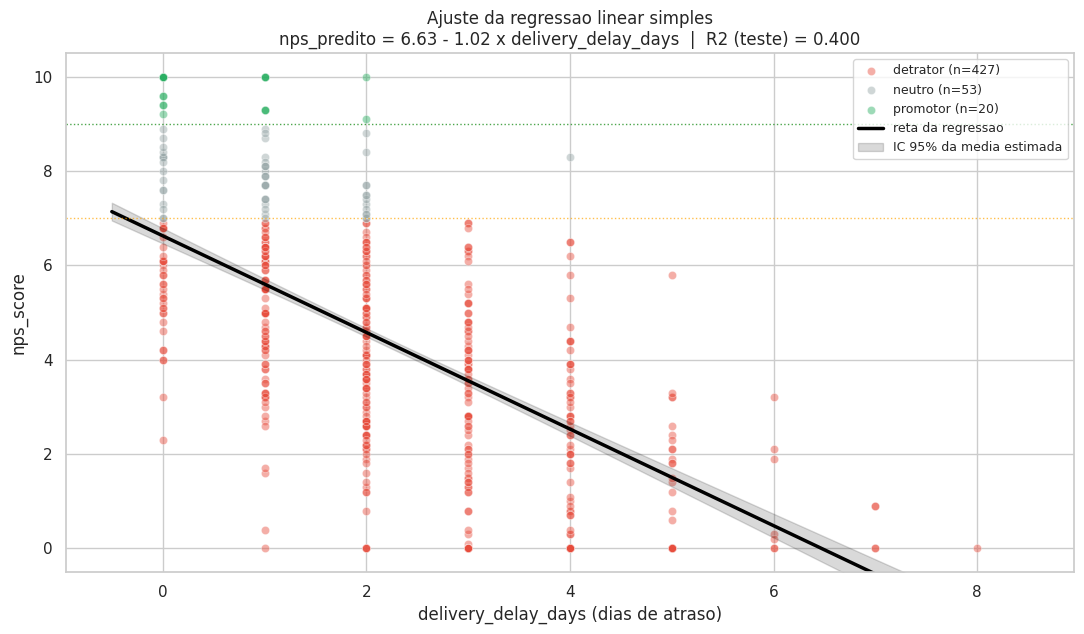

In [5]:
# Cores semanticas que vamos manter consistentes em todo o trabalho
cores_buckets = {"detrator": "#e74c3c", "neutro": "#95a5a6", "promotor": "#27ae60"}

# Predicoes da regressao em uma grade fina, para tracar a reta suave
grade_atraso = np.linspace(dados["delivery_delay_days"].min() - 0.5,
                           dados["delivery_delay_days"].max() + 0.5,
                           100)
df_grade = pd.DataFrame({"delivery_delay_days": grade_atraso})

# get_prediction retorna intervalo de confianca para a media (mean_ci) e para uma observacao individual
predicao_grade = modelo.get_prediction(df_grade)
resumo_predicao = predicao_grade.summary_frame(alpha=0.05)

# Junta dataset de teste com a categoria do nps observado para colorir
dados_teste_viz = dados.loc[X_teste.index].copy()

fig, eixo = plt.subplots(figsize=(11, 6.5))

# Pontos do teste, coloridos por categoria
for cat in ["detrator", "neutro", "promotor"]:
    pontos = dados_teste_viz[dados_teste_viz["categoria_nps"] == cat]
    eixo.scatter(
        pontos["delivery_delay_days"], pontos["nps_score"],
        alpha=0.45, s=35, color=cores_buckets[cat], edgecolor="white", linewidth=0.5,
        label=f"{cat} (n={len(pontos)})",
    )

# Reta da regressao
eixo.plot(grade_atraso, resumo_predicao["mean"], color="black", linewidth=2.5, label="reta da regressao")

# Faixa de IC 95% para a media estimada
eixo.fill_between(
    grade_atraso, resumo_predicao["mean_ci_lower"], resumo_predicao["mean_ci_upper"],
    color="black", alpha=0.15, label="IC 95% da media estimada",
)

# Linhas tracejadas marcando os cortes canonicos do NPS
eixo.axhline(7, color="orange", linestyle=":", linewidth=1, alpha=0.7)
eixo.axhline(9, color="green",  linestyle=":", linewidth=1, alpha=0.7)

eixo.set_xlabel("delivery_delay_days (dias de atraso)")
eixo.set_ylabel("nps_score")
eixo.set_title(f"Ajuste da regressao linear simples\nnps_predito = {intercepto:.2f} - {abs(slope):.2f} x delivery_delay_days  |  R2 (teste) = {m_teste['R2']:.3f}")
eixo.legend(loc="upper right", fontsize=9)
eixo.set_ylim(-0.5, 10.5)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "5_5_ajuste_regressao.png", dpi=120, bbox_inches="tight")
plt.show()

![Ajuste da regressão linear simples no conjunto de teste](../reports/figures/05_modelagem_regressao/5_5_ajuste_regressao.png)

**Como ler este gráfico:** o eixo X mostra os dias de atraso na entrega; o eixo Y mostra o `nps_score` observado. Cada ponto é um cliente do conjunto de teste, **colorido pela categoria de NPS observada** (vermelho = detrator, cinza = neutro, verde = promotor).

A **linha preta sólida** é a reta da regressão ajustada no conjunto de treino, projetada sobre toda a faixa de atrasos. A **faixa cinza ao redor da reta** é o intervalo de confiança a 95% da média estimada — uma região onde o modelo tem segurança razoável de que a média do NPS naquela faixa de atraso cai. As **linhas tracejadas horizontais** em 7 (laranja) e 9 (verde) marcam os cortes canônicos detrator/neutro/promotor, para dar referência visual.

**O que procurar:** se o modelo estiver capturando bem a relação, a reta deve atravessar a nuvem de pontos por dentro, com aproximadamente metade dos pontos acima e metade abaixo em cada faixa de atraso. As cores ajudam a ver onde o modelo erra mais — se houver muitos pontos verdes (promotores reais) na região onde a reta prevê NPS baixo, é sinal de que o modelo está subestimando esses clientes; o oposto vale para os vermelhos.

A leitura visual confirma vários pontos da seção anterior.

A reta atravessa a nuvem de pontos com inclinação clara para baixo: começa perto de NPS 6,6 quando o atraso é zero e vai descendo cerca de 1 ponto por dia, até cruzar a região dos detratores em torno de 4-5 dias de atraso. A faixa cinza do IC 95% é estreita, o que dá segurança de que a média estimada por faixa de atraso é confiável.

O ponto importante é a **dispersão vertical em cada coluna de atraso**. Mesmo entre clientes que tiveram exatamente 2 dias de atraso, há uma variedade enorme de notas: alguns são detratores (pontos vermelhos lá embaixo), alguns são neutros (cinzas), e até alguns são promotores (verdes mais raros lá em cima). O modelo prevê a **média** dessa coluna, mas nenhum cliente individual cai exatamente na média. Essa é a fonte do erro absoluto de 1,58 pontos que vimos na seção anterior.

Outra observação útil é que **o modelo tende a errar na ponta dos atrasos**. Para clientes com 8 dias de atraso (extremo direito), a reta prevê NPS abaixo de zero, o que é matematicamente previsto pela equação mas operacionalmente sem sentido (NPS não vai abaixo de 0). Isso é uma limitação típica de regressão linear quando aplicada fora do intervalo central dos dados, e é mais um motivo para o modelo ser usado como **indicação de tendência**, não como previsão pontual literal.

A próxima seção olha exatamente para onde o modelo erra mais, examinando os resíduos.

## 5.6 Análise de resíduos

Resíduo é a diferença entre o que o modelo previu e o que aconteceu de verdade. Para cada cliente do conjunto de teste, posso calcular `residuo = nps_observado - nps_predito`. Resíduo positivo significa que o cliente foi mais satisfeito do que o modelo esperava; negativo significa o contrário.

Olhar para a distribuição dos resíduos é a forma de checar se a regressão linear faz sentido para esse problema. Três coisas que deveriam acontecer se o modelo for adequado:

- A média dos resíduos deve ficar próxima de zero (modelo não está sistematicamente otimista nem pessimista).
- O tamanho típico do erro deve ser parecido em toda a faixa de previsões (não é maior para clientes com muito atraso, nem para clientes com pouco).
- A distribuição dos erros deve ser próxima de uma curva normal, simétrica em torno de zero.

Vou olhar essas três coisas em conjunto.

Estatisticas dos residuos:
  Media:            -0.042 (esperado: proximo de 0)
  Desvio padrao:     1.948 (igual ao RMSE: 1.946)
  Minimo:           -5.603
  Maximo:            5.770
  Assimetria:        0.071 (esperado: proximo de 0)



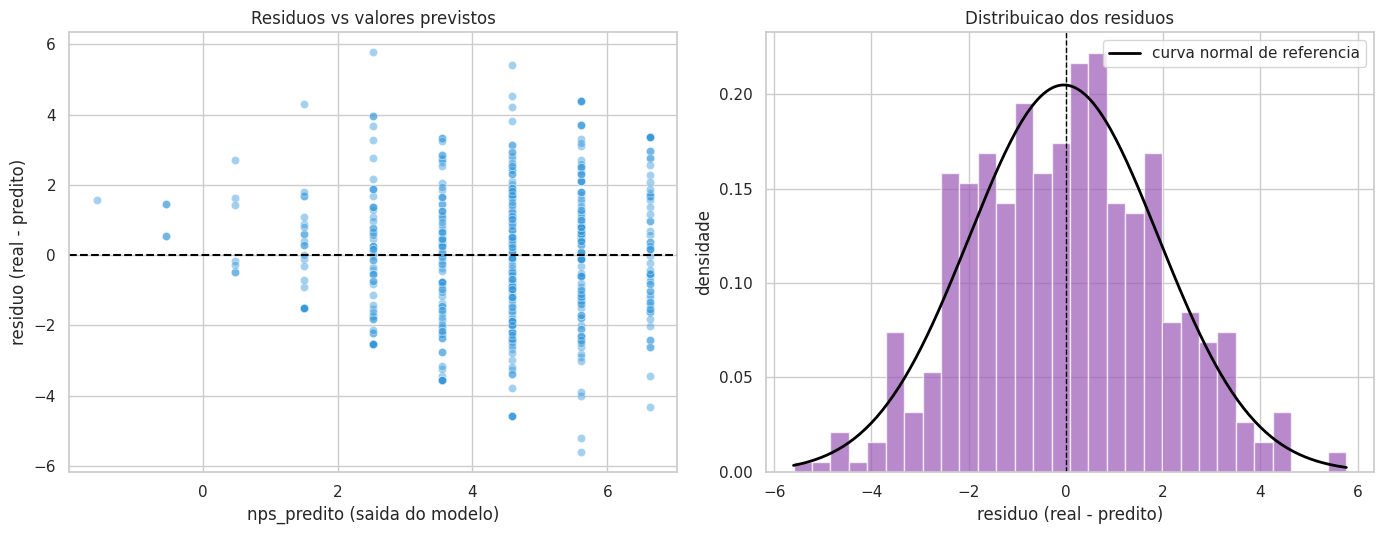

In [6]:
from scipy import stats

# Calcula residuos no conjunto de teste
y_pred_teste = modelo.predict(dados_teste)
residuos = y_teste - y_pred_teste

print(f"Estatisticas dos residuos:")
print(f"  Media:           {residuos.mean():>7.3f} (esperado: proximo de 0)")
print(f"  Desvio padrao:   {residuos.std():>7.3f} (igual ao RMSE: {m_teste['RMSE']:.3f})")
print(f"  Minimo:          {residuos.min():>7.3f}")
print(f"  Maximo:          {residuos.max():>7.3f}")
print(f"  Assimetria:      {stats.skew(residuos):>7.3f} (esperado: proximo de 0)")
print()

# Visualizacoes em grid 1x2
fig, eixos = plt.subplots(1, 2, figsize=(14, 5.5))

# Esquerda: residuos vs valores previstos (deve ser nuvem aleatoria sem padrao)
eixos[0].scatter(y_pred_teste, residuos, alpha=0.45, s=35, color="#3498db", edgecolor="white", linewidth=0.5)
eixos[0].axhline(0, color="black", linestyle="--", linewidth=1.5)
eixos[0].set_xlabel("nps_predito (saida do modelo)")
eixos[0].set_ylabel("residuo (real - predito)")
eixos[0].set_title("Residuos vs valores previstos")

# Direita: histograma dos residuos com curva normal de referencia
eixos[1].hist(residuos, bins=30, color="#9b59b6", edgecolor="white", density=True, alpha=0.7)
# Curva normal teorica com mesma media e desvio
x_grid = np.linspace(residuos.min(), residuos.max(), 200)
curva_normal = stats.norm.pdf(x_grid, loc=residuos.mean(), scale=residuos.std())
eixos[1].plot(x_grid, curva_normal, color="black", linewidth=2, label="curva normal de referencia")
eixos[1].axvline(0, color="black", linestyle="--", linewidth=1)
eixos[1].set_xlabel("residuo (real - predito)")
eixos[1].set_ylabel("densidade")
eixos[1].set_title("Distribuicao dos residuos")
eixos[1].legend(loc="upper right")

fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "5_6_analise_residuos.png", dpi=120, bbox_inches="tight")
plt.show()

![Análise de resíduos: dispersão e distribuição](../reports/figures/05_modelagem_regressao/5_6_analise_residuos.png)

**Como ler este gráfico:** dois painéis, um para cada checagem de premissa.

**Painel esquerdo:** o eixo X é o `nps_predito` que o modelo gerou para cada cliente, e o eixo Y é o resíduo (real menos predito). Cada ponto é um cliente do teste. A **linha tracejada horizontal em zero** é a referência de "previsão perfeita". O ideal é que os pontos formem uma **nuvem aleatória** ao redor dessa linha, sem mostrar padrão sistemático: nem inclinação, nem leque que abre para um dos lados, nem curvatura. Padrão visível indica que algo importante não está sendo capturado pelo modelo.

**Painel direito:** histograma dos resíduos com a **curva normal de referência** (linha preta) calculada com a mesma média e desvio padrão dos resíduos. O histograma deveria seguir aproximadamente o formato dessa curva, com pico em zero e caudas simétricas. Se o histograma estiver muito puxado para um lado, ou tiver duas montanhas, ou cair com forma diferente da normal, é sinal de problema.

A leitura é em geral favorável ao modelo, com algumas ressalvas pequenas.

**Painel esquerdo (resíduos vs predito):** os pontos se espalham em uma nuvem razoavelmente uniforme em torno da linha de zero, sem padrão de "leque" ou curvatura forte. A dispersão dos resíduos é parecida em todas as faixas de previsão, ou seja, o modelo não erra mais para clientes com muito atraso do que para clientes com pouco. Olhando com mais cuidado, dá para notar que os resíduos são levemente negativos para previsões mais baixas e levemente positivos para previsões mais altas, sinal de uma curvatura sutil que o modelo linear não captura. Mas é um efeito pequeno.

**Painel direito (distribuição):** o histograma segue bem o formato da curva normal de referência. A média dos resíduos está praticamente em zero (-0,04), e a assimetria é desprezível (skew = 0,07, com 0 sendo perfeitamente simétrico). As caudas dos resíduos vão de cerca de -5,6 a +5,8, o que é coerente com erros típicos de aproximadamente 2 pontos de NPS observados no MAE da seção anterior.

### Veredito sobre as premissas

As três premissas que importam para regressão linear estão razoavelmente atendidas: média dos resíduos perto de zero, tamanho do erro consistente em toda a faixa de previsão, e distribuição próxima de uma curva normal. Pequenas violações existem (a leve curvatura sistemática nos extremos), mas não são suficientes para invalidar o modelo dentro do escopo de uso prático.

A implicação prática é que **dá para confiar no modelo dentro da faixa típica de atrasos** (digamos, entre 0 e 5 dias, onde mora a maior parte dos clientes). Para casos extremos, o modelo continua útil como indicação de tendência, mas o erro absoluto pode ser maior do que a média de 1,58 ponto. A próxima seção examina exatamente onde o modelo acerta bem e onde erra mais, para deixar essa interpretação ainda mais concreta.

## 5.7 Limites do modelo

O R² de 0,40 e o MAE de 1,58 são números agregados; eles dizem como o modelo se sai em média no conjunto de teste. Mas a média esconde onde o modelo acerta bem e onde erra mais. Esta seção quebra o erro por faixa de atraso para deixar isso visível, e fecha com uma reflexão sobre quando vale usar esse modelo na prática.

Vou usar quatro faixas de atraso com significado de negócio: clientes sem atraso, com atraso leve (1-2 dias), atraso moderado (3-4 dias) e atraso severo (5 dias ou mais).

Erro absoluto por faixa de atraso (no conjunto de teste):
                          mae  desvio    n
faixa                                     
Sem atraso (0d)         1.591   1.086   62
Atraso leve (1-2d)      1.630   1.180  251
Atraso moderado (3-4d)  1.598   1.146  151
Atraso severo (5+d)     1.103   0.834   36

MAE geral no teste: 1.577


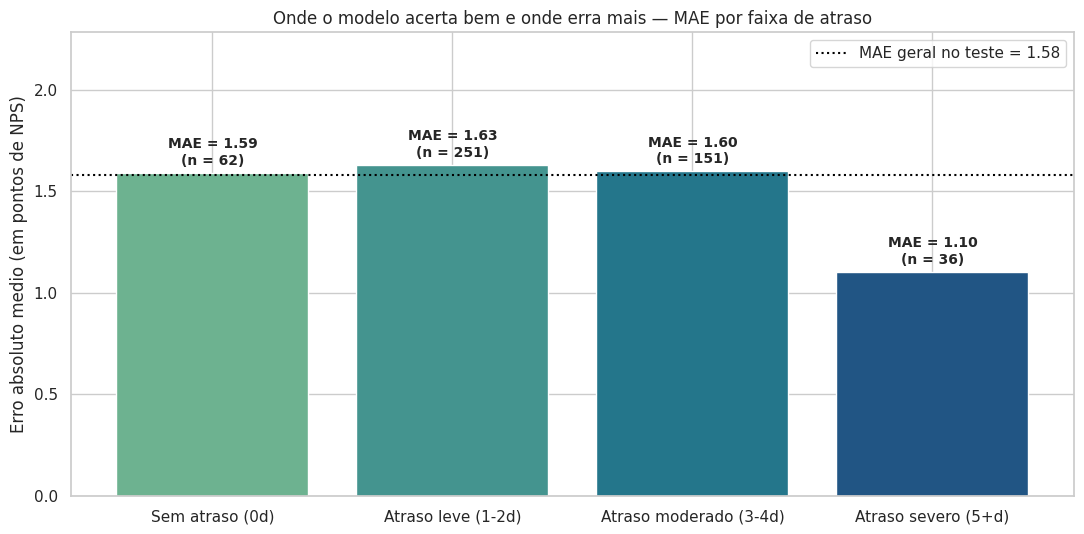

In [7]:
# Faixas de negocio para o atraso
faixa_atraso = pd.cut(
    dados_teste["delivery_delay_days"],
    bins=[-0.5, 0.5, 2.5, 4.5, 100],
    labels=["Sem atraso (0d)", "Atraso leve (1-2d)", "Atraso moderado (3-4d)", "Atraso severo (5+d)"],
)

# Tabela com erro por faixa
diagnostico = pd.DataFrame({
    "faixa": faixa_atraso,
    "real": y_teste.values,
    "predito": y_pred_teste.values,
})
diagnostico["erro_abs"] = (diagnostico["real"] - diagnostico["predito"]).abs()

erro_por_faixa = diagnostico.groupby("faixa", observed=True)["erro_abs"].agg(
    mae="mean", desvio="std", n="count"
).round(3)
print("Erro absoluto por faixa de atraso (no conjunto de teste):")
print(erro_por_faixa.to_string())
print()
print(f"MAE geral no teste: {m_teste['MAE']:.3f}")

# Bar chart do MAE por faixa
fig, eixo = plt.subplots(figsize=(11, 5.5))
ordem = list(erro_por_faixa.index)
valores = erro_por_faixa["mae"].values

# Cores: gradiente azul-roxo conforme aumenta o atraso
paleta = sns.color_palette("crest", n_colors=len(ordem))
barras = eixo.bar(ordem, valores, color=paleta, edgecolor="white")

# Anota MAE e n em cada barra
for i, (mae, n) in enumerate(zip(erro_por_faixa["mae"].values, erro_por_faixa["n"].values)):
    eixo.text(i, mae + 0.04, f"MAE = {mae:.2f}\n(n = {n})", ha="center", fontsize=10, fontweight="bold")

# Linha horizontal com o MAE geral
eixo.axhline(m_teste["MAE"], color="black", linestyle=":", linewidth=1.5,
             label=f"MAE geral no teste = {m_teste['MAE']:.2f}")

eixo.set_ylim(0, max(valores) * 1.4)
eixo.set_ylabel("Erro absoluto medio (em pontos de NPS)")
eixo.set_title("Onde o modelo acerta bem e onde erra mais — MAE por faixa de atraso")
eixo.legend(loc="upper right")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "5_7_erro_por_faixa.png", dpi=120, bbox_inches="tight")
plt.show()

![Erro absoluto médio por faixa de atraso](../reports/figures/05_modelagem_regressao/5_7_erro_por_faixa.png)

**Como ler este gráfico:** o eixo X tem as quatro faixas de atraso ordenadas do mais leve para o mais severo. A altura de cada barra é o **erro absoluto médio (MAE)** em pontos de NPS naquela faixa, ou seja, em média quanto o modelo erra para cada cliente do grupo. A anotação acima de cada barra mostra o MAE exato e o tamanho do grupo (n).

A **linha pontilhada preta horizontal** marca o MAE geral do conjunto de teste (1,58), servindo como referência. Faixas com barra acima da linha são onde o modelo erra mais que a média; faixas abaixo são onde ele erra menos.

A leitura é direta. Nas três primeiras faixas (sem atraso, atraso leve, atraso moderado), o erro fica praticamente igual, em torno de 1,6 ponto, ou seja, o MAE do dataset inteiro. Faixa por faixa, o modelo se comporta de forma consistente nesses cenários, que juntos representam aproximadamente 93% do conjunto de teste.

A surpresa fica na faixa de atraso severo: o erro cai para 1,10. Isso parece contraintuitivo (era de esperar que a previsão piorasse para casos extremos), mas faz sentido olhando para o que está acontecendo. Cliente com 5 ou mais dias de atraso quase sempre dá nota de NPS baixa, ou seja, há menos variação dentro desse grupo. O modelo prevê NPS baixo para todos eles e acerta com mais frequência. Em estatística, esse efeito acontece quando o sinal é forte e a variabilidade residual é menor.

### Quando vale usar esse modelo na prática

A análise sustenta uma recomendação clara sobre o uso do modelo, com seus limites bem definidos.

O modelo é **adequado para indicar tendência e priorizar ações**. Se a empresa quer um sistema que, dado um pedido com X dias de atraso, gere um indicador "este cliente provavelmente vai detratar", o modelo cumpre esse papel: a equação é simples, interpretável, e os erros são uniformes entre faixas. Casos típicos de uso seriam alarmes operacionais ("clientes com mais de 4 dias de atraso entram em fila de contato proativo"), priorização de tickets do SAC, ou painéis de monitoramento de qualidade da entrega.

O modelo **não é adequado para previsão pontual da nota individual**. O erro absoluto de 1,6 ponto significa que, na prática, um cliente que o modelo previu como tendo NPS 6,0 pode na verdade ter dado nota 4,4 ou 7,6, com igual frequência. Em uma escala de 0 a 10 com fronteiras canônicas em 7 e 9, isso é o suficiente para mudar a categoria do cliente. O modelo não deve ser usado como base para ações que dependam da nota exata de cada um.

### O trade-off entre simplicidade e precisão

Vale registrar o que se ganha e o que se perde com a escolha de um modelo simples. O ganho é todo na interpretabilidade: a equação cabe em uma linha, qualquer gestor entende a história ("cada dia de atraso reduz o NPS em 1 ponto"), e o modelo pode ser auditado em planilha. A perda é a precisão preditiva: aproximadamente 16 pontos percentuais de R² em relação ao modelo agregado da seção 4.10 (0,40 vs 0,56).

Para o público desta entrega (storytelling executivo + projeto acadêmico), o modelo simples é a escolha certa. Se a empresa real quisesse colocar isso em produção como sistema crítico, valeria considerar o modelo mais completo da EDA, ou ir para abordagens não-lineares como árvores e gradient boosting. Mas isso é fase posterior, fora do escopo do trabalho atual.

## 5.8 Conclusão da fase

A regressão linear simples com `delivery_delay_days` como único preditor cumpriu o que se propôs: gerou um modelo enxuto, interpretável e estatisticamente válido, com desempenho razoável em dados não vistos.

### Síntese do desempenho

A equação ajustada é:

> `nps_predito = 6,63 - 1,02 × delivery_delay_days`

No conjunto de teste, o modelo atinge R² de 0,40 e erro absoluto médio de 1,58 ponto de NPS. Comparado ao baseline ingênuo (que sempre prevê a média), o modelo reduz o erro em aproximadamente 24%. A análise de resíduos confirmou que as premissas básicas da regressão linear estão atendidas dentro do uso esperado.

Em comparação com o modelo agregado da seção 4.10, que usava todas as variáveis e atingia R² de 0,56, o modelo simples fica aproximadamente 16 pontos percentuais abaixo. Esse é o preço da simplicidade — e é um preço aceitável para o contexto do projeto.

### Como o modelo poderia ser usado na empresa

Três usos práticos saem direto do que vimos:

- **Alarme operacional em tempo real.** A partir de um certo número de dias de atraso, o modelo prevê NPS abaixo da fronteira de detrator (NPS < 7). Aplicando a equação inversa, isso acontece quando o atraso passa de aproximadamente 0 dias — ou seja, qualquer atraso já coloca o cliente no risco. Para um alarme prático, faria sentido escolher um corte mais conservador, como 3 dias, que prevê NPS abaixo de 4 (detração forte).

- **Priorização de fila de SAC e contato proativo.** Quando o sistema operacional detectar atraso crescente em um pedido, o modelo dá uma estimativa imediata da nota provável. Isso permite priorizar contatos proativos (ligação, mensagem, oferta de cupom) para os pedidos com maior previsão de detração, antes da pesquisa de NPS chegar.

- **Painel executivo com NPS projetado.** Com dados operacionais em fluxo contínuo, é possível calcular um NPS estimado da base toda em qualquer momento, sem esperar a próxima rodada de pesquisa. Isso transforma o NPS de indicador atrasado em indicador antecipado, exatamente o que o projeto se propunha desde o notebook 01.

### Por que parar em modelo simples

A escolha de não complicar tem três motivos. O primeiro é interpretabilidade: a equação cabe em uma frase, qualquer gestor entende, e isso vale mais que precisão extra para apresentação executiva. O segundo é manutenção: um modelo de duas constantes (intercepto e slope) é trivial de manter e auditar; um modelo com 14 variáveis exige cuidado contínuo. O terceiro é o ganho marginal: ir do modelo simples para o agregado custa complexidade alta para acrescentar 16 pontos de R², um trade-off que só vale em contexto de produção real com modelo crítico, não para projeto acadêmico de demonstração.

### Implicações para a próxima fase (notebook 06)

Para a classificação, vou adotar uma abordagem coerente com o modelo simples. Em vez de usar uma técnica nova (regressão logística), vou aplicar um **threshold sobre as previsões da regressão linear** desta fase, transformando previsões numéricas em decisões binárias do tipo "este cliente é provavelmente detrator". Essa abordagem mantém o modelo único, simplifica a explicação para a banca, e fica dentro do escopo das técnicas vistas em aula.

A próxima fase também vai precisar lidar com o desbalanceamento da base (84% detratores), discutindo critérios para escolher o threshold ideal e métricas além de acurácia simples.